# Config

In [1]:
! git clone https://github.com/gcao88/scene-segmentation.git

Cloning into 'scene-segmentation'...
remote: Enumerating objects: 241, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 241 (delta 0), reused 0 (delta 0), pack-reused 238 (from 2)
Receiving objects: 100% (241/241), 452.97 MiB | 56.52 MiB/s, done.
Resolving deltas: 100% (128/128), done.
Updating files: 100% (49/49), done.


In [2]:
%cd /content/scene-segmentation
! pip install -q -r requirements.txt

/content/scene-segmentation
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 1.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 503.8 kB/s eta 0:00:000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 936.3 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 695.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 603.4 kB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.


In [3]:
! git pull

Already up to date.


In [4]:
import os

os.environ.setdefault("USE_TF", "0")

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

# Import ADE20K

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

scene_parse_150.py: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/20210 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3352 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Number of training samples: 20210
Number of validation samples: 2000
Number of test samples: 3352


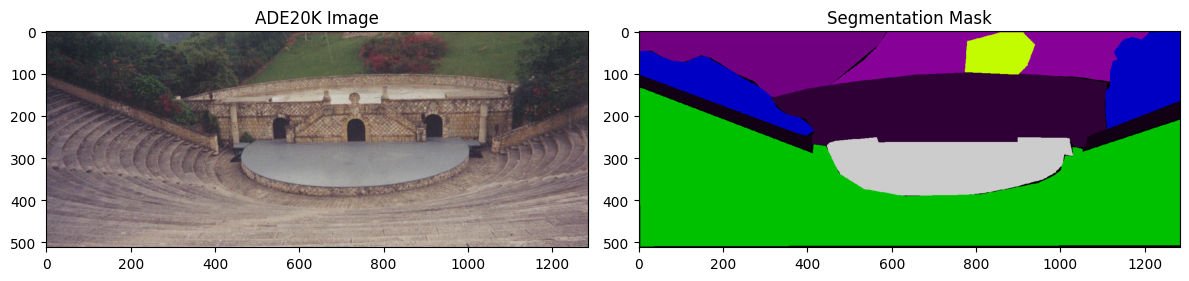

In [5]:
dataset_train = load_dataset("zhoubolei/scene_parse_150", split="train", trust_remote_code=True)
dataset_val = load_dataset("zhoubolei/scene_parse_150", split="validation", trust_remote_code=True)
dataset_test = load_dataset("zhoubolei/scene_parse_150", split="test", trust_remote_code=True)

print(f"Number of training samples: {len(dataset_train)}")
print(f"Number of validation samples: {len(dataset_val)}")
print(f"Number of test samples: {len(dataset_test)}")

# Plot A Sample Image + Segmentation Mask

sample = dataset_train[0]
image = sample["image"]
mask = sample["annotation"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title("ADE20K Image")

axes[1].imshow(np.array(mask), cmap="nipy_spectral")
axes[1].set_title("Segmentation Mask")

plt.tight_layout()
plt.show()

In [6]:
! nvidia-smi

Fri May  1 21:00:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Import Segformer-B0

In [7]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
processor = SegformerImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

print(f"Loaded model: {model.config._name_or_path}")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loaded model: nvidia/segformer-b0-finetuned-ade-512-512


# Train baselines

In [ ]:
from run_experiments import run_all

processor.do_reduce_labels = True

results = run_all(
    dataset_train, dataset_val, processor, model,
    configs=[
        'ce+lovasz+abl',
    ],
    num_epochs=1,
    batch_size=16,
    max_train_samples=None,
    max_val_samples=None,
    save_dir='checkpoints',
    compile_model=True
)

# Train baseline `ce` epoch-by-epoch

In [18]:
from run_experiments import run_all

processor.do_reduce_labels = True

results = run_all(
    dataset_train, dataset_val, processor, model,
    configs=['ce+bdou'],
    num_epochs=1,
    batch_size=16,
    max_train_samples=None,
    max_val_samples=None,
    save_dir='checkpoints',
    save_name='segformer_ce_bdou_10e.pt',
    checkpoint_path='checkpoints/segformer_ce_bdou_9e.pt',
    compile_model=True,
)


  ce+bdou
  [resume] loaded weights from checkpoints/segformer_ce_bdou_9e.pt


eval: 100%|██████████| 125/125 [01:22<00:00,  1.52it/s]


  epoch 1: train_loss=1.0031  {'mIoU': 0.35933130979537964, 'BF1@3': 0.48527641015466, 'BF1@5': 0.5849246529903775, 'BF1@9': 0.6976047711140259, 'BF1@12': 0.7487485060566303, 'BIoU': 0.24876629925061436}
  saved -> checkpoints/segformer_ce_bdou_10e.pt

Configuration                mIoU      BF1@3      BF1@5      BF1@9     BF1@12       BIoU
----------------------------------------------------------------------------------------
ce+bdou                    0.3593     0.4853     0.5849     0.6976     0.7487     0.2488
  [gpu] 0.81/42.41 GB used after ce+bdou


In [17]:
results = run_all(
    dataset_train, dataset_val, processor, model,
    configs=['ce+bdou'],
    num_epochs=1,
    batch_size=16,
    max_train_samples=None,
    max_val_samples=None,
    save_dir='checkpoints',
    save_name='segformer_ce_bdou_9e.pt',
    checkpoint_path='checkpoints/segformer_ce_bdou_8e.pt',
    compile_model=True,
)


  ce+bdou
  [resume] loaded weights from checkpoints/segformer_ce_bdou_8e.pt


eval: 100%|██████████| 125/125 [01:22<00:00,  1.52it/s]


  epoch 1: train_loss=1.0118  {'mIoU': 0.35954880714416504, 'BF1@3': 0.4856538086524866, 'BF1@5': 0.5859689654918816, 'BF1@9': 0.6987582698852302, 'BF1@12': 0.7497988751104655, 'BIoU': 0.24872960654543352}
  saved -> checkpoints/segformer_ce_bdou_9e.pt

Configuration                mIoU      BF1@3      BF1@5      BF1@9     BF1@12       BIoU
----------------------------------------------------------------------------------------
ce+bdou                    0.3595     0.4857     0.5860     0.6988     0.7498     0.2487
  [gpu] 0.81/42.41 GB used after ce+bdou


# Evaluate baselines

In [ ]:
from run_experiments import evaluate_all_checkpoints

results = evaluate_all_checkpoints(
    'checkpoints', model, dataset_val, processor,
    max_val_samples=None, batch_size=4, include_baseline=True
)
